In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# Euclid imports
from cloelite.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelite.observables.Comet_spectro import CometSpectroPower
from cloelite.summary_statistics.legendre_multiples import LegendreMultipoles

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

Warning! "libgrid.so" not found, bispectrum binning options will not be available.


In [2]:
zs = np.linspace(1e-4, 3, 100)

background_fiducial = CAMBBackground(H0=67.7, 
                            Omega_cdm0=0.28067408193677466, 
                            Omega_b0=0.04902591806322532, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.966, 
                            As = 2e-9,
                            gamma_MG = 0.545)


background = CAMBBackground(H0=67.7, 
                            Omega_cdm0=0.26067408193677466, 
                            Omega_b0=0.04902591806322532, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.966, 
                            As = 2e-9,
                            gamma_MG = 0.545)
linear_perturbations = CAMBLinearPerturbations(background, zs)
pk_values_linear = linear_perturbations.matter_power_spectrum()

Note: redshifts have been re-sorted (earliest first)


In [3]:
parameters = {
 'ns': 0.96,
 'As': 2.1,
 'w0': -1.0,
 'wa': 0.0,
 'b1': 1.412,
 'b2': 0.695,
 'bG2': -0.156,
 'bGam3': 0.323,
 'c0': 30.948,
 'c2': 46.233,
 'c4': 10.057,
 'cnlo': 0.0,
 'NP0': 1.056,
 'NP20': 0.0,
 'NP22': 0.0,
 'fout': 0.0,
 'sigmaz': 0.0,
 'z': 1.0,
 'h': 0.67,
 'wc': 0.1333233,
 'wb': 0.0219961}

In [4]:
comet_pk2 = CometSpectroPower(background=background,
                             background_fiducial=background_fiducial,
                             redshifts= [1.1],
                             NLmodel='EFT',
                             **parameters) 
                             

/Users/guadalupe.canasherr/miniforge3/envs/camb/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.4.1.post1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
k = np.logspace(-3, np.log10(0.3), 101)
mu_min = 0.00001
mu_max = 1.0
mu_samp = 101
mu_grid = np.linspace(mu_min, mu_max, mu_samp)

In [7]:
comet_pk2.Pk2d_rsd(k=k, mu=mu_grid)

/Users/guadalupe.canasherr/miniforge3/envs/camb/lib/python3.9/site-packages/comet/PTEmu.py:1107: RuntimeWarning: invalid value encountered in scalar divide
  dlP_min = np.log10(np.abs(Pell[id_min+2]/Pell[id_min]))
/Users/guadalupe.canasherr/miniforge3/envs/camb/lib/python3.9/site-packages/comet/PTEmu.py:1114: RuntimeWarning: invalid value encountered in scalar divide
  if np.abs(Pell[id_max]/Pell[id_max-2]) < 2 \


array([            nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
        6.02898510e+04,  6.13701766e+04,  6.23152477e+04,  6.31194317e+04,
        6.37605424e+04,  6.42191470e+04,  6.44807243e+04,  6.45316384e+04,
        6.43540489e+04,  6.39330003e+04,  6.32632333e+04,  6.23473443e+04,
        6.11585204e+04,  5.97083880e+04,  5.80346036e+04,  5.61365922e+04,
        5.40447168e+04,  

/Users/guadalupe.canasherr/miniforge3/envs/camb/lib/python3.9/site-packages/comet/PTEmu.py:1107: RuntimeWarning: invalid value encountered in scalar divide
  dlP_min = np.log10(np.abs(Pell[id_min+2]/Pell[id_min]))
/Users/guadalupe.canasherr/miniforge3/envs/camb/lib/python3.9/site-packages/comet/PTEmu.py:1114: RuntimeWarning: invalid value encountered in scalar divide
  if np.abs(Pell[id_max]/Pell[id_max-2]) < 2 \


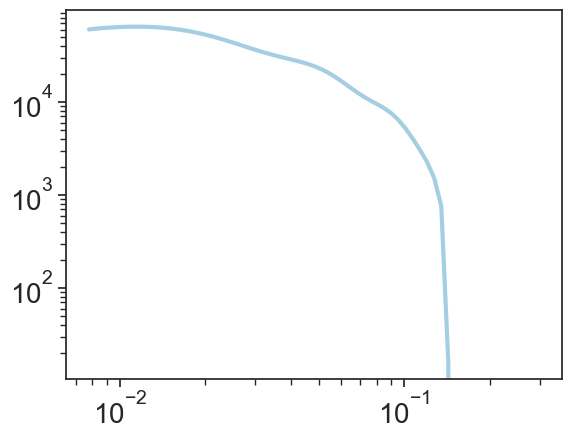

In [ ]:
plt.loglog(k, comet_pk2.Pk2d_rsd(k=k, mu=mu_grid))

In [9]:
pkell = LegendreMultipoles(spectro_power= comet_pk2,
                 nbar=1e-4, sigmaz=0, fout= 1, redshift=1)

In [22]:
pkells = pkell.power_multipoles(k=k, ells=[0, 2, 4], parameters=comet_pk2.parameters)

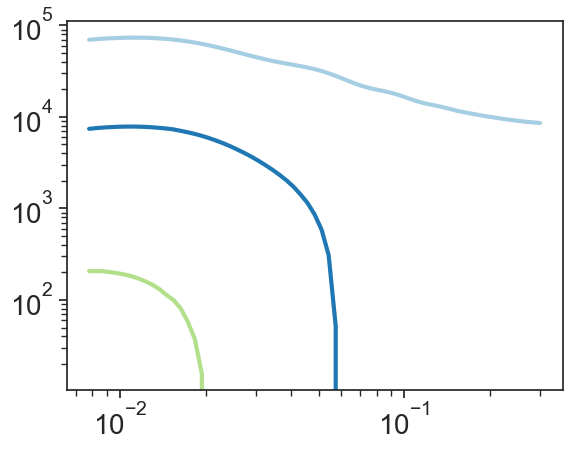

In [ ]:
plt.loglog(k, pkells['ell0'])
plt.loglog(k, pkells['ell2'])
plt.loglog(k, pkells['ell4']) #I think I messed up something, but you get the flow